In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
plt.rcParams['figure.figsize'] = (30,8)
plt.style.use('fivethirtyeight')

In [2]:
ratings = pd.read_csv('ml100k/u.data', sep='\t', names = ['user_id', 'movie_id', 'rating'], usecols=[0,1,2])

In [3]:
ratings.head()

,user_id,movie_id,rating
0,0,50,5
1,0,172,5
2,0,133,1
3,196,242,3
4,186,302,3


# EDA

1682

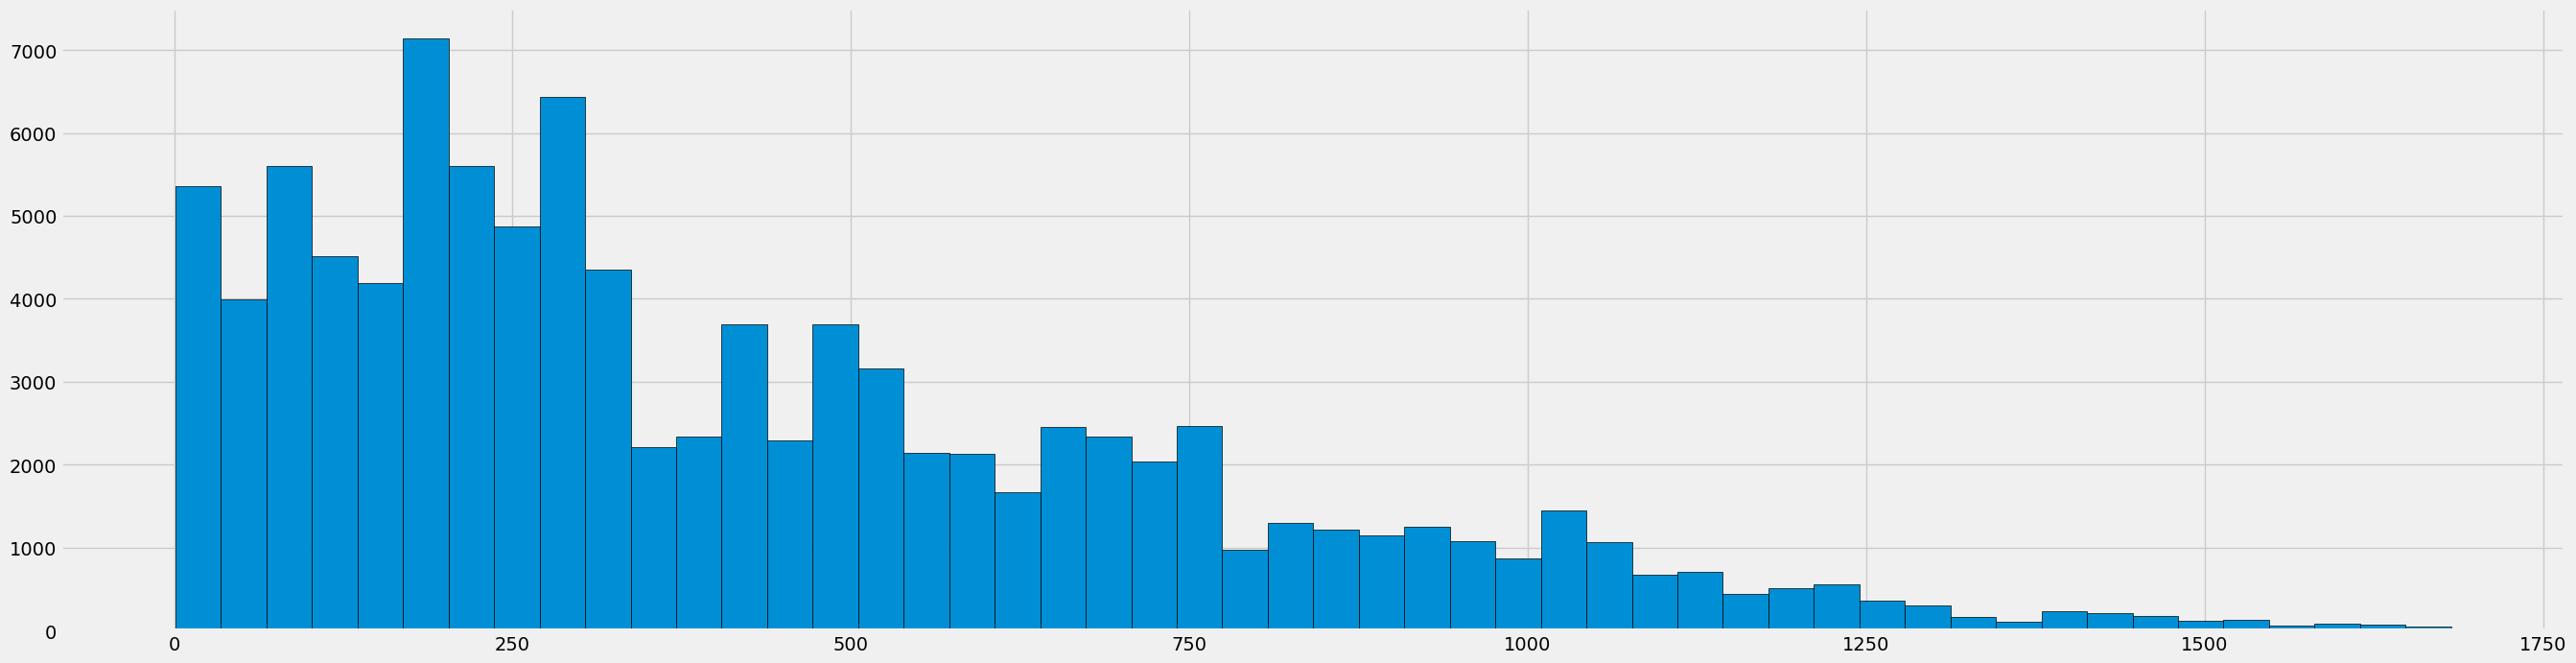

In [4]:
plt.hist(ratings['movie_id'], bins = 50, edgecolor='black')
ratings['movie_id'].max()

## most popular movies

<Axes: xlabel='movie_id'>

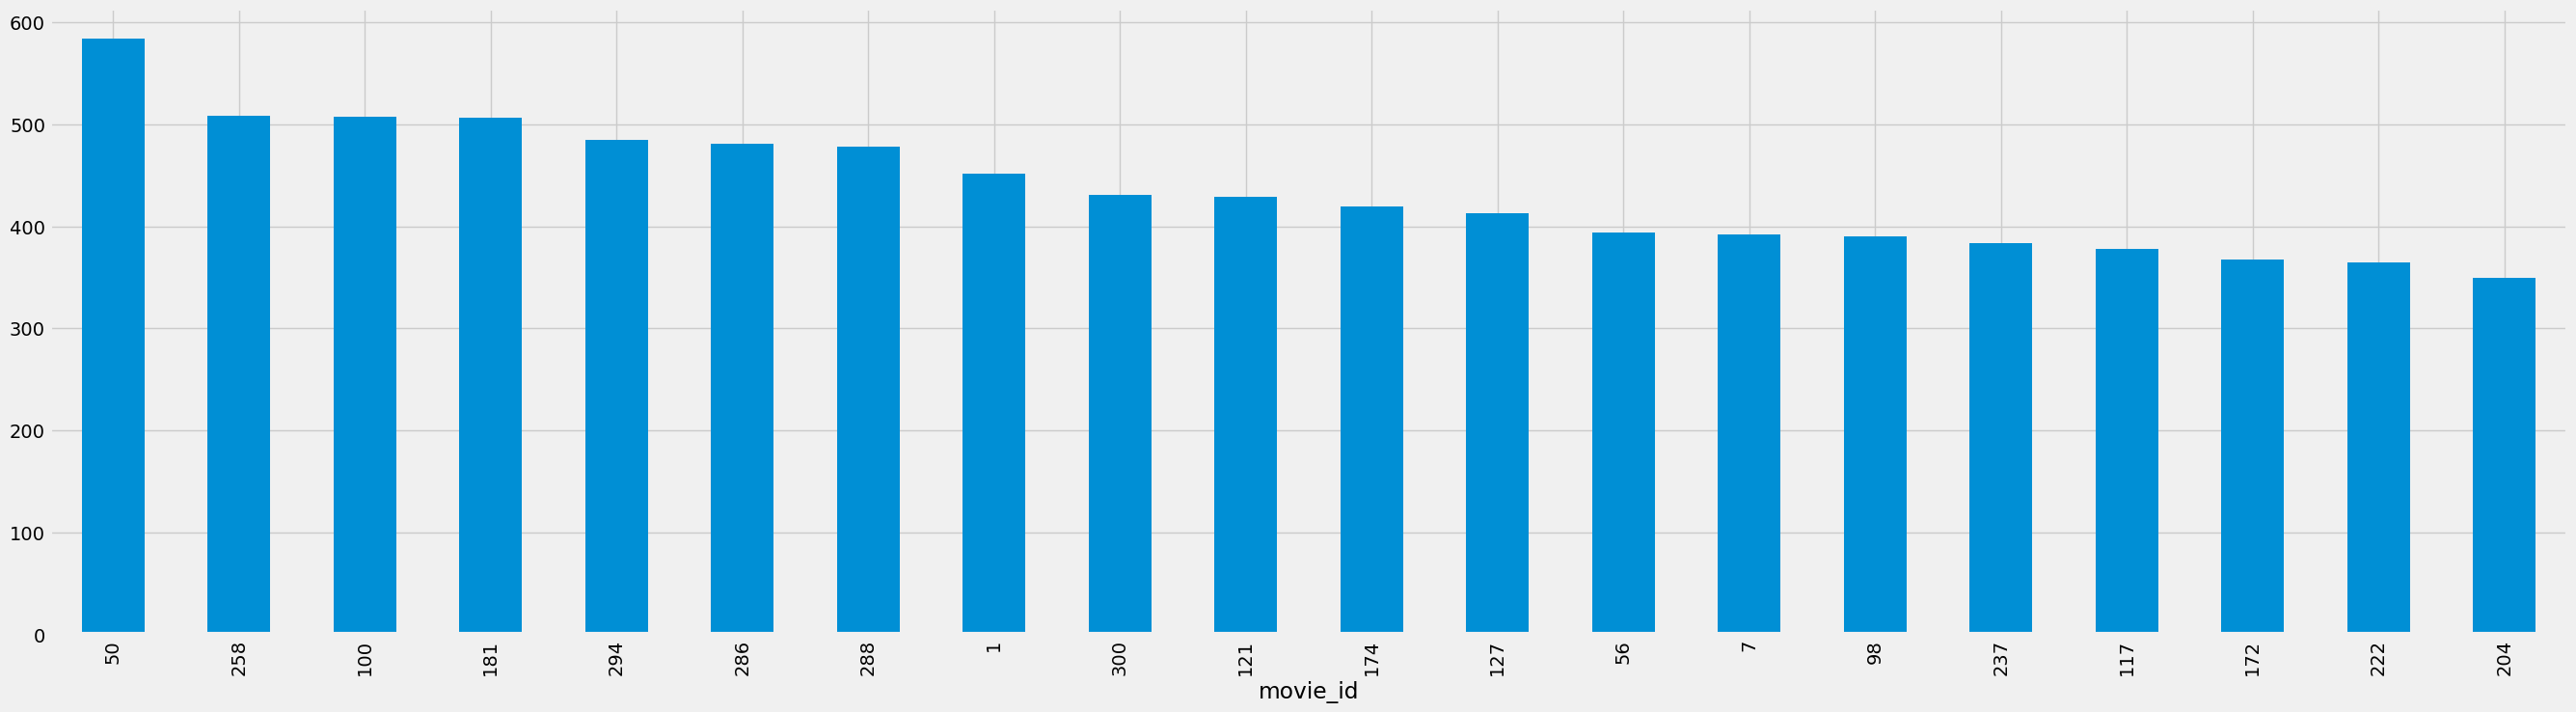

In [5]:
ratings['movie_id'].value_counts()[:20].plot(kind='bar')

## Popularity of movies

In [6]:
ratings.head(6)

,user_id,movie_id,rating
0,0,50,5
1,0,172,5
2,0,133,1
3,196,242,3
4,186,302,3
5,22,377,1


In [7]:
movie_property = ratings.groupby('movie_id').agg({'rating':np.mean, 'user_id':np.size})

C:\Users\DELL\AppData\Local\Temp\ipykernel_9068\3868313004.py:1: FutureWarning: The provided callable <function mean at 0x0000021DF76A4540> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  movie_property = ratings.groupby('movie_id').agg({'rating':np.mean, 'user_id':np.size})


In [8]:
movie_property.columns = ["mean","size"]

In [9]:
movie_property.head()

,mean,size
movie_id,,
1,3.878319,452
2,3.206107,131
3,3.033333,90
4,3.550239,209
5,3.302326,86


# Normalizing

In [10]:
minimum = np.mean(movie_property['size'])
maximum = np.max(movie_property['size'])
movie_property['popularity'] = movie_property['size'].apply(lambda x: (x-minimum)/(maximum-minimum))

In [11]:
movie_property.head()

,mean,size,popularity
movie_id,,,
1,3.878319,452,0.748353
2,3.206107,131,0.136395
3,3.033333,90,0.058232
4,3.550239,209,0.285095
5,3.302326,86,0.050606


In [61]:
title = []
l = """movie id | movie title | release date | video release date | IMDb URL | unknown | Action | Adventure | Animation |
              Children's | Comedy | Crime | Documentary | Drama | Fantasy |
              Film-Noir | Horror | Musical | Mystery | Romance | Sci-Fi |
              Thriller | War | Western """.split("|")
for i in l:
    title.append(i.strip())
print(title)

['movie id', 'movie title', 'release date', 'video release date', 'IMDb URL', 'unknown', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [81]:
movie_df=pd.read_csv("ml100k/u.item",encoding='latin',sep="|",names=title)

In [82]:
movie_df.head()

,movie id,movie title,release date,video release date,IMDb URL,unknown,Action,Adventure,Animation,Children's,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [83]:
movie_df.columns

Index(['movie id', 'movie title', 'release date', 'video release date',
       'IMDb URL', 'unknown', 'Action', 'Adventure', 'Animation', 'Children's',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
       'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War',
       'Western'],
      dtype='object')

In [84]:
movie_df.index = movie_df['movie id']

In [85]:
movie_df.head()

,movie id,movie title,release date,video release date,IMDb URL,unknown,Action,Adventure,Animation,Children's,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movie id,,,,,,,,,,,,,,,,,,,,,
1,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
2,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [86]:
all_properties = movie_property.join(movie_df)

In [87]:
movie_df.columns

Index(['movie id', 'movie title', 'release date', 'video release date',
       'IMDb URL', 'unknown', 'Action', 'Adventure', 'Animation', 'Children's',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
       'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War',
       'Western'],
      dtype='object')

In [88]:
all_properties.columns

Index(['mean', 'size', 'popularity', 'movie id', 'movie title', 'release date',
       'video release date', 'IMDb URL', 'unknown', 'Action', 'Adventure',
       'Animation', 'Children's', 'Comedy', 'Crime', 'Documentary', 'Drama',
       'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance',
       'Sci-Fi', 'Thriller', 'War', 'Western'],
      dtype='object')

In [89]:
#movie_df=movie_df[['Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']]

In [90]:
all_properties.drop(['unknown','size','movie title', 'release date',
       'video release date', 'IMDb URL',],axis =1, inplace=True)

In [91]:
all_properties.head()

,mean,popularity,movie id,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movie_id,,,,,,,,,,,,,,,,,,,,,
1,3.878319,0.748353,1,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3.206107,0.136395,2,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,3.033333,0.058232,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,3.550239,0.285095,4,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5,3.302326,0.050606,5,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


In [92]:
movie_name = movie_df['movie title']

In [93]:
from scipy.spatial.distance import cosine 

In [94]:
abs(all_properties.loc[1,'popularity']-all_properties.loc[2,'popularity'])

np.float64(0.6119587208215033)

In [95]:
def calculateDistance(id1,id2):
    # print("**In CalculateDistance before calculating popular Distance")
    pop_dis = abs(all_properties.loc[id1,'popularity']-all_properties.loc[id2,'popularity'])
    # print("**In CalculateDistance before calculating genre Distance")
    genre_dis = cosine(all_properties.loc[id1,'Action':'Western'],all_properties.loc[id2,'Action':'Western'])
    # print("**In CalculateDistance before calculating Total Distance")
    total_distance = pop_dis+genre_dis
    return total_distance

In [96]:
from operator import itemgetter

In [97]:
l = [(1,0.33), (2,0.44), (3,0.23),(4,0.55)]
l.sort(reverse=True)
print(l)
l.sort(key = itemgetter(1))
print(l)

[(4, 0.55), (3, 0.23), (2, 0.44), (1, 0.33)]
[(3, 0.23), (1, 0.33), (2, 0.44), (4, 0.55)]


In [98]:
def getNeighbours(movie_id,k=5):
    # print("**In Get Neighbours before CalculateDistance")
    distance = [(mid,calculateDistance(movie_id,mid)) for mid in all_properties.index if mid !=movie_id]
    # print("**In Get Neighbours after calculate Distance")
    distance.sort(key=itemgetter(1))
    distance = distance[:k]
    return [ mid for mid, dis in distance]

In [115]:
distance = [(mid,calculateDistance(50,mid)) for mid in all_properties.index]
distance[1][1]

C:\ProgramData\anaconda3\Lib\site-packages\scipy\spatial\distance.py:682: RuntimeWarning: invalid value encountered in scalar divide
  dist = 1.0 - uv / math.sqrt(uu * vv)


np.float64(1.3472075181135936)

In [99]:
def similar_movie(movie_id, k =5):
    # print("**Before Get Neighbours")
    ids = getNeighbours(movie_id,k)
    # print("**AFter Get Neighbours")
    print(f"So {k} Nearest Neighbours of {movie_name[movie_id]} ")
    # print("Rating\t\tName")
    for mid in ids:
        name = movie_name[mid]
        ratings = all_properties.loc[mid,'mean']
        print(f"{ratings}\t{name}")

In [100]:
similar_movie(50,10)

C:\ProgramData\anaconda3\Lib\site-packages\scipy\spatial\distance.py:682: RuntimeWarning: invalid value encountered in scalar divide
  dist = 1.0 - uv / math.sqrt(uu * vv)


So 10 Nearest Neighbours of Star Wars (1977) 
4.007889546351085	Return of the Jedi (1983)
4.206521739130435	Empire Strikes Back, The (1980)
3.438228438228438	Independence Day (ID4) (1996)
3.66027397260274	Star Trek: First Contact (1996)
4.252380952380952	Raiders of the Lost Ark (1981)
3.2322274881516586	Starship Troopers (1997)
4.172839506172839	Princess Bride, The (1987)
3.7203065134099615	Jurassic Park (1993)
3.930513595166163	Indiana Jones and the Last Crusade (1989)
3.693121693121693	Rock, The (1996)


In [101]:
all_properties.loc[1,'Action':'Western']

Action         0.0
Adventure      0.0
Animation      1.0
Children's     1.0
Comedy         1.0
Crime          0.0
Documentary    0.0
Drama          0.0
Fantasy        0.0
Film-Noir      0.0
Horror         0.0
Musical        0.0
Mystery        0.0
Romance        0.0
Sci-Fi         0.0
Thriller       0.0
War            0.0
Western        0.0
Name: 1, dtype: float64

In [102]:
all_properties.loc[2,'popularity']

np.float64(0.1363947023920842)

In [ ]:
all_prope

In [120]:
from sklearn.neighbors import NearestNeighbors

In [124]:
reco = NearestNeighbors(n_neighbors=10)

In [125]:
reco

,n_neighbors,10
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,n_jobs,None


In [126]:
reco.fit(all_properties)

,n_neighbors,10
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,n_jobs,None
